# Setup and Data Loading

In [1]:
%pip install matplotlib

import math 
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from statistics import mean, median, stdev

You should consider upgrading via the '/Users/christophstein/Documents/jku/qcs-rl/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
LOG_DIR = "logs"

In [3]:
test_df = pd.read_csv(f"{LOG_DIR}/eval.monitor.csv", skiprows=1)
test_df.head()

,r,l,t
0,-90.01,10,28.952910
1,1000.00,1,28.953255
2,-180.01,10,28.955581
3,-180.01,10,28.957872
4,-180.01,10,28.960152


In [4]:
EPISODE_CUTOFF = 10 # must be same as in training code.

# Data Preparation

In [5]:
def compute_success_rate(data: pd.DataFrame) -> float:
    return len(data[data < EPISODE_CUTOFF]) / len(data)

In [6]:
print(test_df.columns)
test_df["steps"] = test_df["l"].cumsum(axis=0)

# moving average over episode rewards
test_df["r_avg"] = test_df["r"].rolling(50).mean()

# moving average over (circuit) length
test_df["l_avg"] = test_df["l"].rolling(50).mean()

# compute success percentage

test_df["succ_pct"] = test_df["l"].rolling(50).aggregate(
    compute_success_rate
)

test_df.head()

Index(['r', 'l', 't'], dtype='object')


,r,l,t,steps,r_avg,l_avg,succ_pct
0,-90.01,10,28.952910,10,NaN,NaN,NaN
1,1000.00,1,28.953255,11,NaN,NaN,NaN
2,-180.01,10,28.955581,21,NaN,NaN,NaN
3,-180.01,10,28.957872,31,NaN,NaN,NaN
4,-180.01,10,28.960152,41,NaN,NaN,NaN


In [7]:
# Select every nth datapoint to avoid plot clutter
test_df = test_df[test_df.index % 100 == 0]

# Data Analysis

## Plot Reward over Steps 

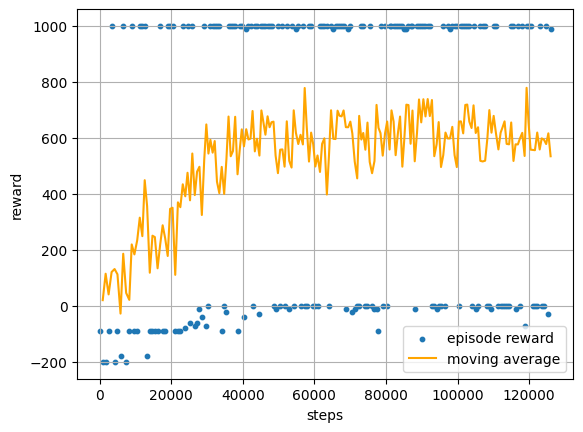

In [8]:
ax = plt.subplot()


ax.scatter(test_df["steps"], test_df["r"], label="episode reward", s=10)
ax.plot(test_df["steps"], test_df["r_avg"], label="moving average", c="orange")

ax.set_xlabel("steps")
ax.set_ylabel("reward")

plt.legend()
plt.grid()
plt.show()

## Plot Circuit Length over Steps

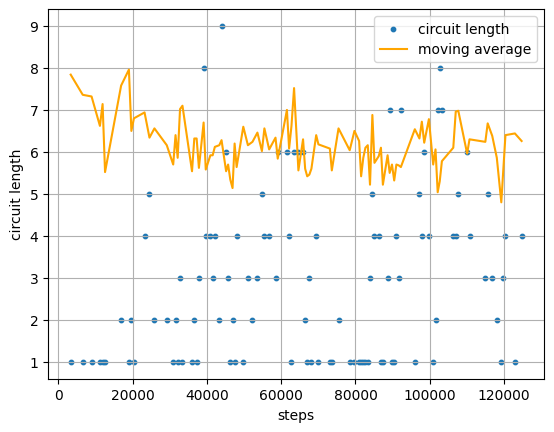

In [9]:
ax = plt.subplot()

# Only log circuit length where a circuit was found
test_df_succ = test_df[test_df["l"] < EPISODE_CUTOFF]

ax.scatter(test_df_succ["steps"], test_df_succ["l"], label="circuit length", s=10)
ax.plot(test_df_succ["steps"], test_df_succ["l_avg"], label="moving average", c="orange")

ax.set_xlabel("steps")
ax.set_ylabel("circuit length")

plt.legend()
plt.grid()
plt.show()

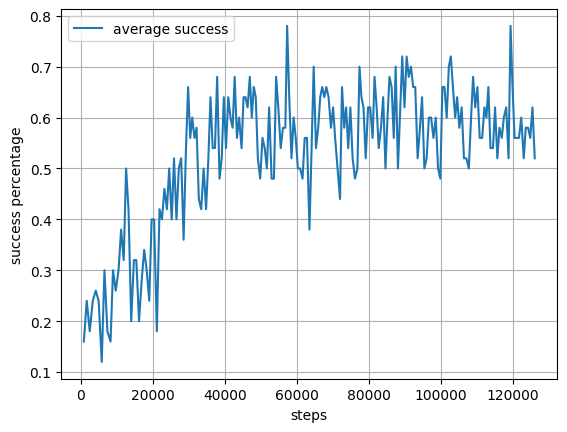

In [10]:
ax = plt.subplot()

ax.plot(test_df["steps"], test_df["succ_pct"], label="average success")

ax.set_xlabel("steps")
ax.set_ylabel("success percentage")

plt.legend()
plt.grid()
plt.show()